In [121]:
import pandas as pd


evaluation = pd.read_csv("extrait_eval.csv")
sirh = pd.read_csv("extrait_sirh.csv")
sondage = pd.read_csv("extrait_sondage.csv")


# Identification du jeu de données

## [evaluation]

**Qualitative ordinal (note) [1 à 5]:**

------------------------------------------------------

* satisfaction_employee_environnement
* note_evaluation_precedente
* niveau_hierarchique_poste
* satisfaction_employee_nature_travail
* satisfaction_employee_equipe
* satisfaction_employee_equilibre_pro_perso
* note_evaluation_actuelle

**Quantitative continue**

------------------------------------------------------

* augementation_salaire_precedente (%) [11% à 25%]

**Qualitative binaire (bool str)**

------------------------------------------------------

* heure_supplementaires [Oui / Non]

**Qualitative nominale (unique id)**

------------------------------------------------------

* eval_number : [E_1 à E_2068]

## [sirh]

**Quantitative discrète**

------------------------------------------------------

* age (nb annèes) [18 à 60]
* revenu_mensuel (€) [1009 à 19999]
* nombre_experiences_precedentes (nb) [0 à 9]
* nombre_heures_travailless (nb) [=80] !!
* annee_experience_totale (nb) [0 à 40]
* annees_dans_l_entreprise (nb) [0 à 40]
* annees_dans_le_poste_actuel (nb) [0 à 18]


**Qualitative binaire (bool str)**

------------------------------------------------------

* genre [M / F]

**Qualitative nominale (unique id)**

------------------------------------------------------

* id_employee : [1 à 2068]

**Qualitative nominale (classes)**

------------------------------------------------------

* statut_marital [Divorcé(e), Célibataire, Marié(e)]
* departement [Consulting, Commercial, Ressources Humaines]
* poste
```
[
    Cadre Commercial           326
    Assistant de Direction     292
    Consultant                 259
    Tech Lead                  145
    Manager                    131
    Senior Manager             102
    Représentant Commercial     83
    Directeur Technique         80
    Ressources Humaines         52   
]
```

## [sondage]

**Qualitative (bool str)**

------------------------------------------------------

* a_quitte_l_entreprise  [Oui / Non]


**Quantitative discrète**

------------------------------------------------------

* nombre_participation_pee (nb ??années??) [0 à 3]
* nb_formations_suivies (nb) [0 à 6]
* nombre_employee_sous_responsabilite (nb) [=1] !!
* distance_domicile_travail (nb km) [1 à 29]
* niveau_education (nb années ???) [1 à 5]
* annees_depuis_la_derniere_promotion (nb) [0 à 15]
* annes_sous_responsable_actuel (nb) [0 à 17]


**Qualitative nominale (code)**

------------------------------------------------------

* code_sondage [1 à 2068]

# Nettoyage des données

## colonnes inutiles

In [122]:
sirh.drop(inplace=True, columns=["nombre_heures_travailless"])
sondage.drop(inplace=True, columns=["nombre_employee_sous_responsabilite"])

## cellules vides

In [123]:
# on trim les colonnes de type str (supprime les espaces avant/après)
evaluation.astype(str).apply(lambda col: col.str.strip())
sirh.astype(str).apply(lambda col: col.str.strip())
sondage.astype(str).apply(lambda col: col.str.strip())

# vérification des données vides (espaces ou chaine vide)
mask = (evaluation == "")
print("données vides dans evaluation", evaluation[mask.any(axis=1)].shape)

mask = (sirh == "")
print("données vides dans sirh", sirh[mask.any(axis=1)].shape)

mask = (sondage == "")
print("données vides dans sondage", sondage[mask.any(axis=1)].shape)

# suppression des populations ayant une colonne vide (ce n'est pas le cas ici)
#sondage.drop(sondage[mask.any(axis=1)].index, inplace=True)
#sirh.drop(sirh[mask.any(axis=1)].index, inplace=True)
#evaluation.drop(evaluation[mask.any(axis=1)].index, inplace=True)

données vides dans evaluation (0, 10)
données vides dans sirh (0, 11)
données vides dans sondage (0, 11)


## erreurs lexicale

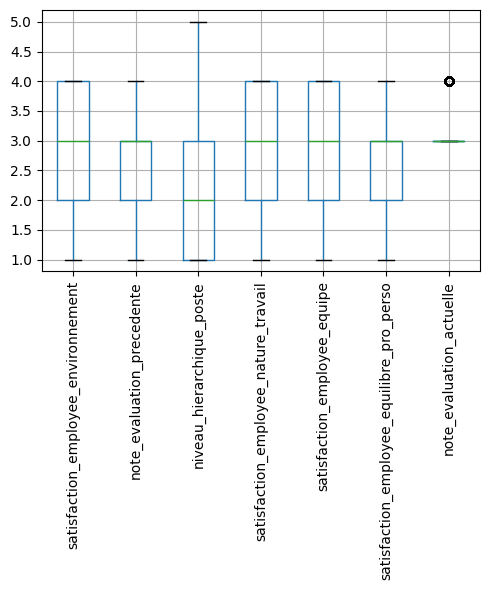

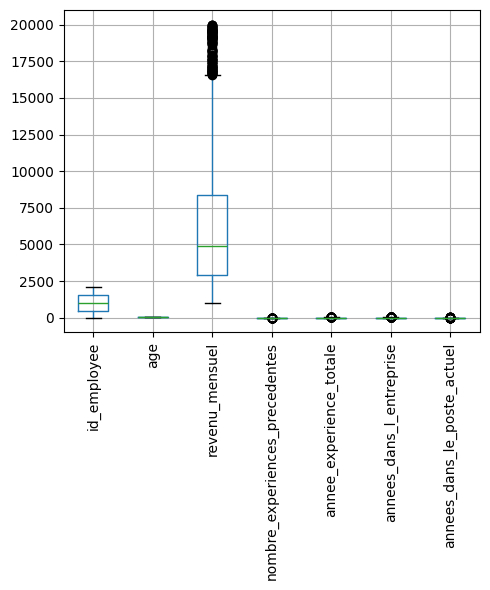

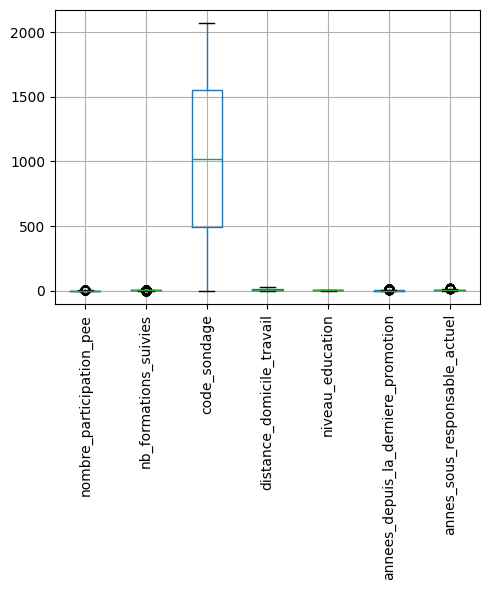

In [124]:
import matplotlib.pyplot as plt

# toutes les valeurs comprises entre 1 et 5 ?
plt.figure(figsize=(5, 6))
evaluation.boxplot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 
plt.figure(figsize=(5, 6))
sirh.boxplot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 
plt.figure(figsize=(5, 6))
sondage.boxplot()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [125]:
evaluation == ""

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1465,False,False,False,False,False,False,False,False,False,False
1466,False,False,False,False,False,False,False,False,False,False
1467,False,False,False,False,False,False,False,False,False,False
1468,False,False,False,False,False,False,False,False,False,False


In [126]:
# affiche le nombre de colonnes ayant au moin un null
print(sondage.columns[sondage.isnull().any()].tolist())
print(sondage.columns[sondage.isna().any()].tolist())
print(evaluation.columns[evaluation.isnull().any()].tolist())
print(evaluation.columns[evaluation.isna().any()].tolist())
print(sirh.columns[sirh.isnull().any()].tolist())
print(sirh.columns[sirh.isna().any()].tolist())


[]
[]
[]
[]
[]
[]
